# EDA — Índices de Provisiones por Riesgo de Crédito
**Fuente:** Comisión para el Mercado Financiero (CMF) — Sistema Bancario Chileno  
**Período:** Enero 2016 — Marzo 2026

## 1. Carga y revisión inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
df_prov = pd.read_csv('../data/processed/provisiones_por_tipo.csv', parse_dates=['fecha'])
df_cart = pd.read_csv('../data/processed/calidad_cartera.csv', parse_dates=['fecha'])

print('provisiones_por_tipo:', df_prov.shape)
print('calidad_cartera:     ', df_cart.shape)

provisiones_por_tipo: (2318, 6)
calidad_cartera:      (2441, 7)


In [3]:
df_prov.head()

,fecha,banco,indice_total,indice_comercial,indice_consumo,indice_vivienda
0,2016-01-01,Banco BTG Pactual Chile,NaN,0.427317,0.427317,0.427317
1,2016-01-01,Banco Bice,NaN,1.252892,1.252892,1.427603
2,2016-01-01,"Banco Bilbao Vizcaya Argentaria, Chile",NaN,1.519819,1.521970,1.218724
3,2016-01-01,Banco Consorcio,NaN,1.626852,1.626852,1.518591
4,2016-01-01,Banco Falabella,NaN,4.563471,4.563471,2.916760


In [4]:
df_prov.describe().round(2)

,fecha,indice_total,indice_comercial,indice_consumo,indice_vivienda
count,2318,1695.00,2159.00,2158.00,1773.00
mean,2020-10-21 13:29:27.385677,2.90,2.93,3.17,2.52
min,2016-01-01 00:00:00,0.04,0.04,0.04,0.09
25%,2018-03-01 00:00:00,1.68,1.66,1.74,1.34
50%,2020-09-01 00:00:00,2.26,2.23,2.36,2.03
75%,2023-06-01 00:00:00,3.27,3.30,3.54,2.78
max,2026-03-01 00:00:00,14.58,15.90,22.52,15.93
std,NaN,2.07,2.13,2.85,2.10


In [5]:
# Cuántos bancos hay y en qué período aparece cada uno
resumen_bancos = (
    df_prov.groupby('banco')['fecha']
    .agg(desde='min', hasta='max', meses='count')
    .sort_values('meses', ascending=False)
)
resumen_bancos

,desde,hasta,meses
banco,,,
Banco BTG Pactual Chile,2016-01-01,2026-03-01,123
Banco Bice,2016-01-01,2026-03-01,123
Banco Consorcio,2016-01-01,2026-03-01,123
Banco Falabella,2016-01-01,2026-03-01,123
Banco Internacional,2016-01-01,2026-03-01,123
Banco Ripley,2016-01-01,2026-03-01,123
Banco de Chile,2016-01-01,2026-03-01,123
Banco de Crédito e Inversiones,2016-01-01,2026-03-01,123
Banco Santander-Chile,2016-01-01,2026-03-01,123


## 2. Evolución del sistema bancario en su conjunto
Promedio mensual de los índices de provisiones para todos los bancos.

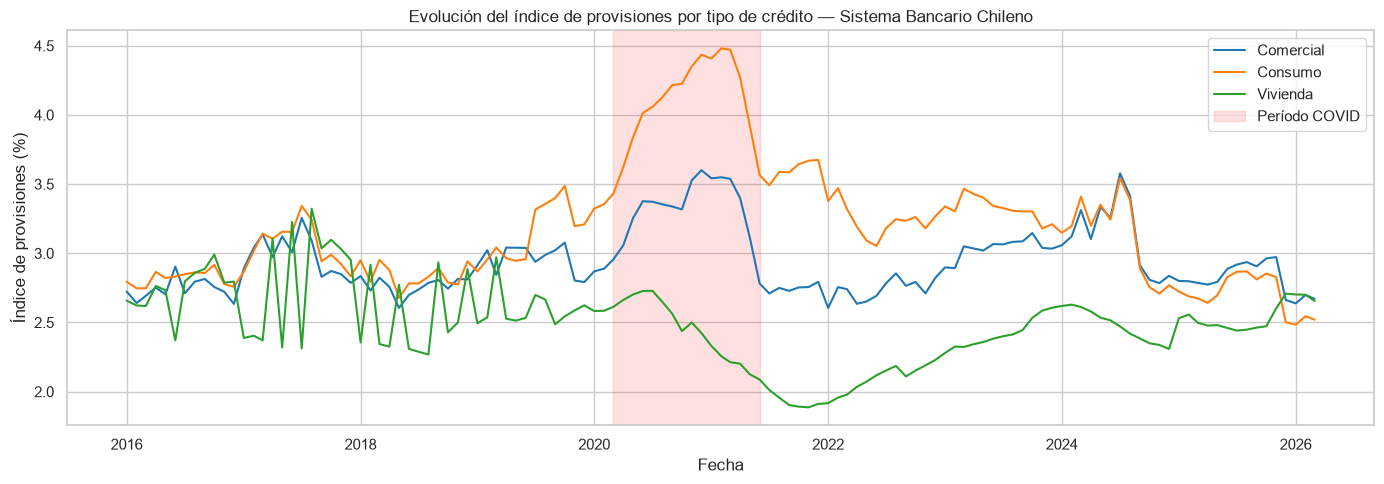

In [6]:
# Promedio mensual del sistema (excluyendo bancos con pocos meses para no sesgar)
sistema = (
    df_prov.groupby('fecha')[['indice_comercial', 'indice_consumo', 'indice_vivienda']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(sistema['fecha'], sistema['indice_comercial'], label='Comercial')
ax.plot(sistema['fecha'], sistema['indice_consumo'],   label='Consumo')
ax.plot(sistema['fecha'], sistema['indice_vivienda'],  label='Vivienda')

# Marcamos COVID
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.12, color='red', label='Período COVID')

ax.set_title('Evolución del índice de provisiones por tipo de crédito — Sistema Bancario Chileno')
ax.set_xlabel('Fecha')
ax.set_ylabel('Índice de provisiones (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Comparativa entre bancos — índice promedio por tipo de crédito

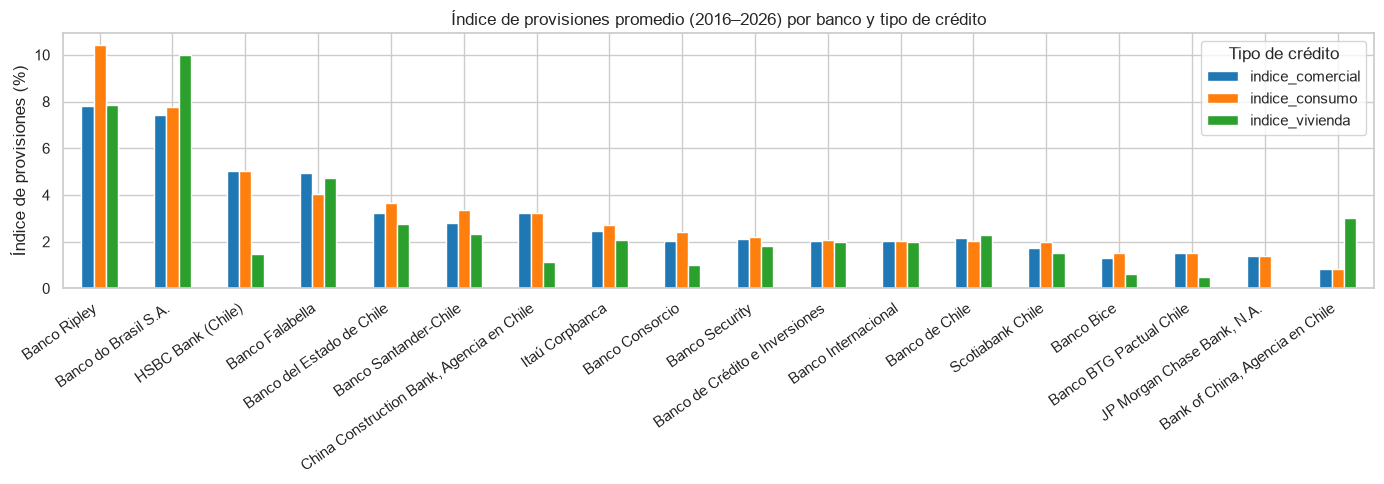

In [7]:
# Solo bancos con presencia significativa (al menos 60 meses de datos)
bancos_principales = resumen_bancos[resumen_bancos['meses'] >= 60].index.tolist()

prom_banco = (
    df_prov[df_prov['banco'].isin(bancos_principales)]
    .groupby('banco')[['indice_comercial', 'indice_consumo', 'indice_vivienda']]
    .mean()
    .round(2)
    .sort_values('indice_consumo', ascending=False)
)

prom_banco.plot(kind='bar', figsize=(14, 5))
plt.title('Índice de provisiones promedio (2016–2026) por banco y tipo de crédito')
plt.ylabel('Índice de provisiones (%)')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Tipo de crédito')
plt.tight_layout()
plt.show()

## 4. Evolución por banco — créditos de consumo
El crédito de consumo es el que más refleja el riesgo minorista.

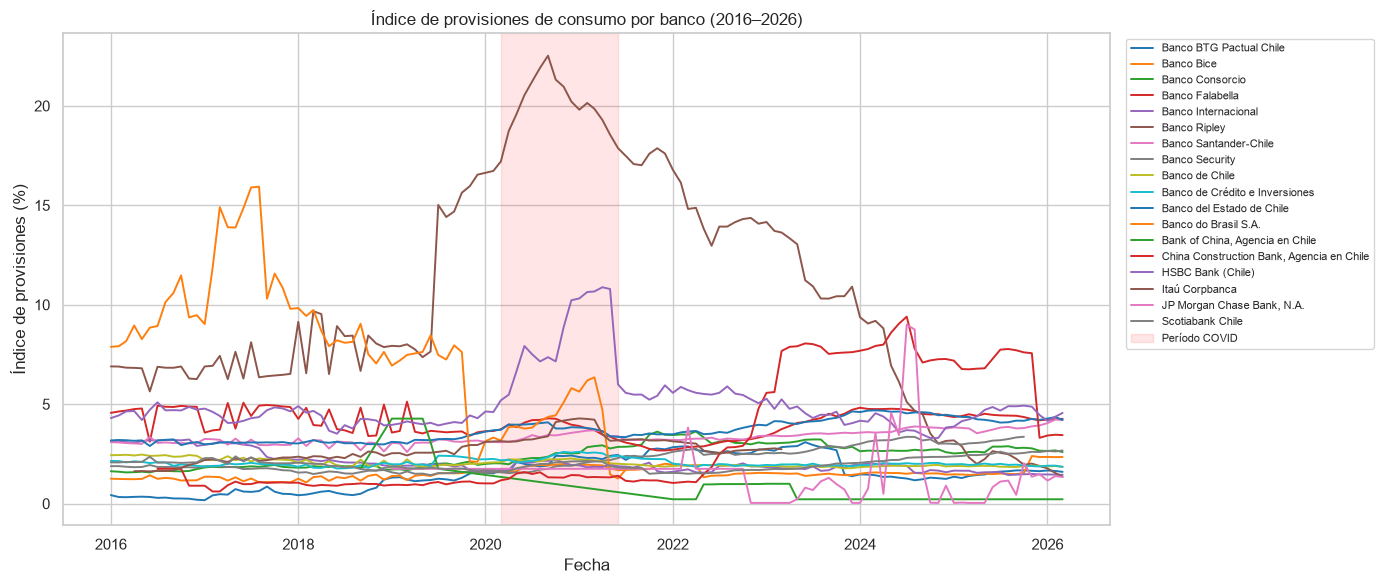

In [8]:
df_consumo = df_prov[df_prov['banco'].isin(bancos_principales)][['fecha', 'banco', 'indice_consumo']].dropna()

fig, ax = plt.subplots(figsize=(14, 6))
for banco, grupo in df_consumo.groupby('banco'):
    ax.plot(grupo['fecha'], grupo['indice_consumo'], label=banco, linewidth=1.4)

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='Período COVID')

ax.set_title('Índice de provisiones de consumo por banco (2016–2026)')
ax.set_ylabel('Índice de provisiones (%)')
ax.set_xlabel('Fecha')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Calidad de cartera — evolución por clasificación

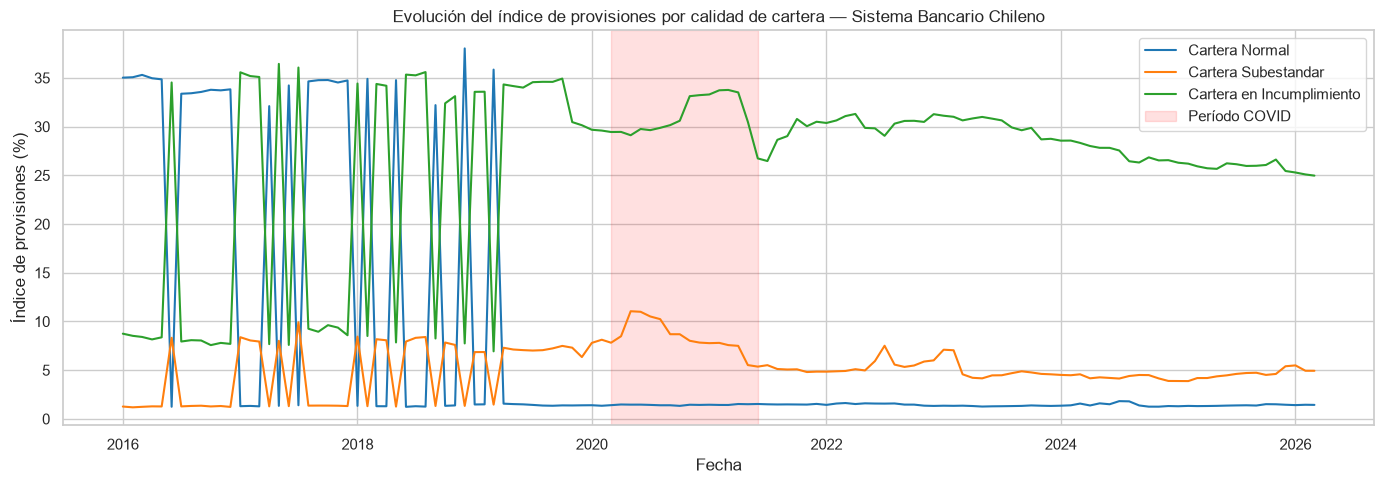

In [9]:
sistema_cart = (
    df_cart.groupby('fecha')[['indice_cartera_normal', 'indice_cartera_subestandar', 'indice_cartera_incumplimiento']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sistema_cart['fecha'], sistema_cart['indice_cartera_normal'],        label='Cartera Normal')
ax.plot(sistema_cart['fecha'], sistema_cart['indice_cartera_subestandar'],   label='Cartera Subestandar')
ax.plot(sistema_cart['fecha'], sistema_cart['indice_cartera_incumplimiento'],label='Cartera en Incumplimiento')

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.12, color='red', label='Período COVID')

ax.set_title('Evolución del índice de provisiones por calidad de cartera — Sistema Bancario Chileno')
ax.set_ylabel('Índice de provisiones (%)')
ax.set_xlabel('Fecha')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Heatmap — índice de consumo por banco y año

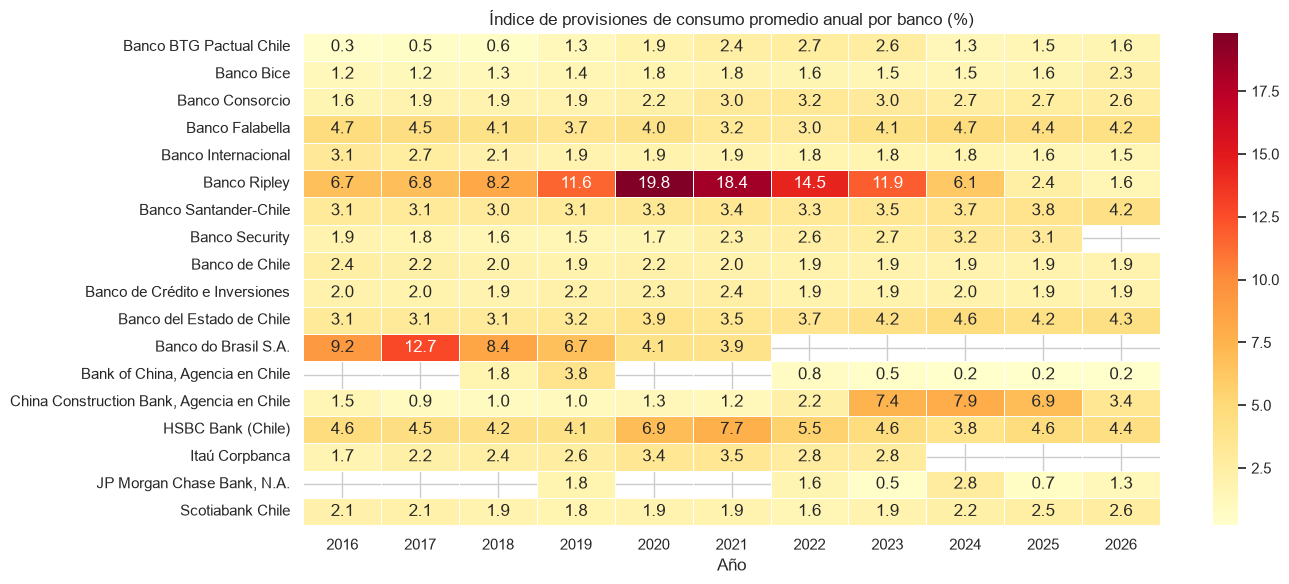

In [10]:
df_heat = df_prov[df_prov['banco'].isin(bancos_principales)].copy()
df_heat['anio'] = df_heat['fecha'].dt.year

pivot = (
    df_heat.groupby(['banco', 'anio'])['indice_consumo']
    .mean()
    .unstack()
    .round(2)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Índice de provisiones de consumo promedio anual por banco (%)')
ax.set_ylabel('')
ax.set_xlabel('Año')
plt.tight_layout()
plt.show()

## 7. Distribución de índices por tipo de crédito

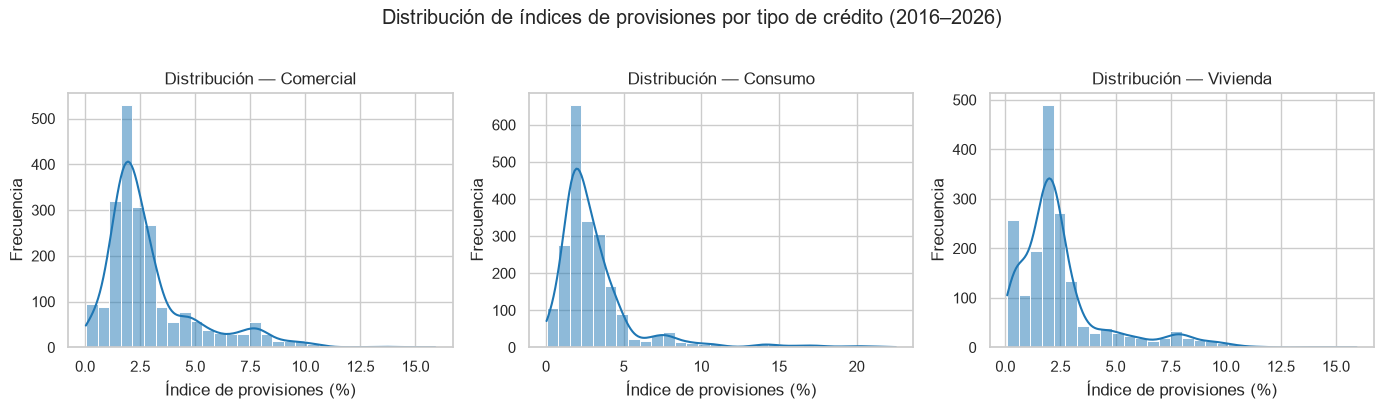

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titulo in zip(axes,
    ['indice_comercial', 'indice_consumo', 'indice_vivienda'],
    ['Comercial', 'Consumo', 'Vivienda']):
    
    data = df_prov[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribución — {titulo}')
    ax.set_xlabel('Índice de provisiones (%)')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de índices de provisiones por tipo de crédito (2016–2026)', y=1.02)
plt.tight_layout()
plt.show()

## 8. Resumen estadístico por banco

In [12]:
resumen_final = (
    df_prov[df_prov['banco'].isin(bancos_principales)]
    .groupby('banco')[['indice_comercial', 'indice_consumo', 'indice_vivienda']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
resumen_final

indice_comercial                     \
                                                      mean   std   min    max   
banco                                                                           
Banco BTG Pactual Chile                               1.53  0.86  0.17   3.09   
Banco Bice                                            1.30  0.21  1.06   2.08   
Banco Consorcio                                       2.01  0.29  1.57   2.84   
Banco Falabella                                       4.92  0.63  3.60   6.09   
Banco Internacional                                   2.04  0.50  1.47   3.22   
Banco Ripley                                          7.79  1.11  6.08  10.54   
Banco Santander-Chile                                 2.78  0.20  2.46   3.28   
Banco Security                                        2.12  0.45  1.55   2.98   
Banco de Chile                                        2.15  0.14  1.87   2.44   
Banco de Crédito e Inversiones                        2.03  0.14  1.76   2.43   
Banco del Estado de Chile                             3.22  0.22  2.88   3.73   
Banco do Brasil S.A.                                  7.42  3.21  1.26  15.90   
Bank of China, Agencia en Chile                       0.81  1.14  0.22   4.28   
China Construction Bank, Agencia en Chile             3.22  2.94  0.48   9.40   
HSBC Bank (Chile)                                     5.02  1.56  3.30  10.87   
Itaú Corpbanca                                        2.46  0.41  1.62   3.43   
JP Morgan Chase Bank, N.A.                            1.40  1.85  0.04   9.00   
Scotiabank Chile                                      1.73  0.26  1.22   2.13   

                                          indice_consumo                     \
                                                    mean   std   min    max   
banco                                                                         
Banco BTG Pactual Chile                             1.53  0.85  0.17   3.09   
Banco Bice                                          1.53  0.29  1.06   2.39   
Banco Consorcio                                     2.42  0.58  1.57   3.63   
Banco Falabella                                     4.04  0.66  2.67   5.13   
Banco Internacional                                 2.04  0.50  1.44   3.22   
Banco Ripley                                       10.40  5.75  1.35  22.52   
Banco Santander-Chile                               3.34  0.32  2.59   4.23   
Banco Security                                      2.21  0.61  1.43   3.36   
Banco de Chile                                      2.03  0.19  1.77   2.47   
Banco de Crédito e Inversiones                      2.05  0.19  1.77   2.61   
Banco del Estado de Chile                           3.67  0.54  2.90   4.69   
Banco do Brasil S.A.                                7.76  3.45  1.26  15.93   
Bank of China, Agencia en Chile                     0.83  1.19  0.22   4.28   
China Construction Bank, Agencia en Chile           3.24  2.92  0.61   9.40   
HSBC Bank (Chile)                                   5.04  1.56  3.30  10.88   
Itaú Corpbanca                                      2.71  0.62  1.62   4.28   
JP Morgan Chase Bank, N.A.                          1.40  1.85  0.04   9.00   
Scotiabank Chile                                    2.00  0.30  1.50   2.67   

                                          indice_vivienda                     
                                                     mean   std   min    max  
banco                                                                         
Banco BTG Pactual Chile                              0.50  0.28  0.20   1.22  
Banco Bice                                           0.60  0.42  0.27   1.50  
Banco Consorcio                                      0.99  0.56  0.40   2.58  
Banco Falabella                                      4.74  0.88  2.86   6.16  
Banco Internacional                                  1.99  0.64  1.06   3.27  
Banco Ripley                                    

## 9. Conclusiones

### Hallazgos principales

**1. Impacto COVID claramente visible en los datos**  
El indice de provisiones de consumo del sistema salto de un promedio de **2.97%** en el periodo pre-COVID (2016-2020) a **4.09%** durante la pandemia (2020-2021), un alza de 1.12 puntos porcentuales. Esto refleja el deterioro real del credito minorista durante la crisis sanitaria.

**2. Recuperacion post-COVID, pero sin volver a niveles anteriores**  
Desde 2022 el indice de consumo bajo a un promedio de **3.13%**, por encima del nivel pre-pandemia. Esto sugiere que parte del deterioro de cartera se mantuvo estructuralmente, posiblemente por efectos de endeudamiento de hogares.

**3. Banco Ripley y Banco Falabella concentran el mayor riesgo de consumo**  
Con promedios de **10.4%** y **4.0%** respectivamente, ambos bancos de retail lideran consistentemente el ranking de riesgo. Esto es esperable dado su foco en credito de consumo masivo, que historicamente tiene mayor probabilidad de incumplimiento.

**4. Banco de Chile y BCI son los mas estables del sistema**  
Con una variacion historica de solo **0.69** y **0.84** puntos entre su minimo y maximo de consumo, ambos bancos muestran la cartera mas consistente del periodo analizado.

**5. El credito de vivienda es el tipo de menor riesgo**  
En todos los anios y para casi todos los bancos, el indice de vivienda se mantiene sistematicamente por debajo de comercial y consumo, lo que es consistente con la naturaleza de activo respaldado de la deuda hipotecaria.

**6. Tendencia a la baja desde 2025**  
El promedio del sistema en consumo bajo de **3.33%** en 2023 a **2.75%** en 2025, la cifra mas baja desde 2016. Esto podria indicar una normalizacion del credito o mejoras en las politicas de evaluacion de riesgo de los bancos.

---
*Nota: Los indices corresponden a provisiones por riesgo de credito sobre colocaciones, expresados en porcentaje. Fuente: CMF Chile.*